# Assignment 12: PCA Visualization Explorer

**Course Outcome**: CO5  
**Topic**: Dimensionality Reduction, 2D Projection & Explained Variance Trade-Off  

### Objectives:
1. Apply Principal Component Analysis (PCA) to compress a high-dimensional dataset (30 features) down to 2 components.
2. Visualize the 2D reduced projection colored by diagnostic class labels.
3. Report and explain the exact explained variance ratio and evaluate the practical implications of information loss.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Setup complete!')

Setup complete!


## 1. Load 30-Dimensional Diagnostic Dataset
We load the Breast Cancer Wisconsin dataset containing 30 geometric nuclear features.

In [2]:
df = pd.read_csv('cancer_dataset.csv')
feature_cols = [c for c in df.columns if c not in ['target', 'diagnosis']]
print(f'Sample Count: {len(df)}, Feature Count: {len(feature_cols)}')
df[feature_cols[:5]].head()

Sample Count: 569, Feature Count: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,17.99,10.38,122.80,1001.0,0.11840
1,20.57,17.77,132.90,1326.0,0.08474
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
4,20.29,14.34,135.10,1297.0,0.10030


## 2. Feature Standardization and 2D PCA Fit
Standardization ensures all features contribute equally to variance regardless of unit scale.

In [3]:
X = df[feature_cols].values
y = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
cum_evr = np.sum(evr)
print(f'PC1 Variance Explained: {evr[0]:.4f} ({evr[0]*100:.2f}%)')
print(f'PC2 Variance Explained: {evr[1]:.4f} ({evr[1]*100:.2f}%)')
print(f'Total 2D Variance Retained: {cum_evr:.4f} ({cum_evr*100:.2f}%)')

PC1 Variance Explained: 0.4427 (44.27%)
PC2 Variance Explained: 0.1897 (18.97%)
Total 2D Variance Retained: 0.6324 (63.24%)


## 3. Visualizing 2D Reduced Space Colored by Class

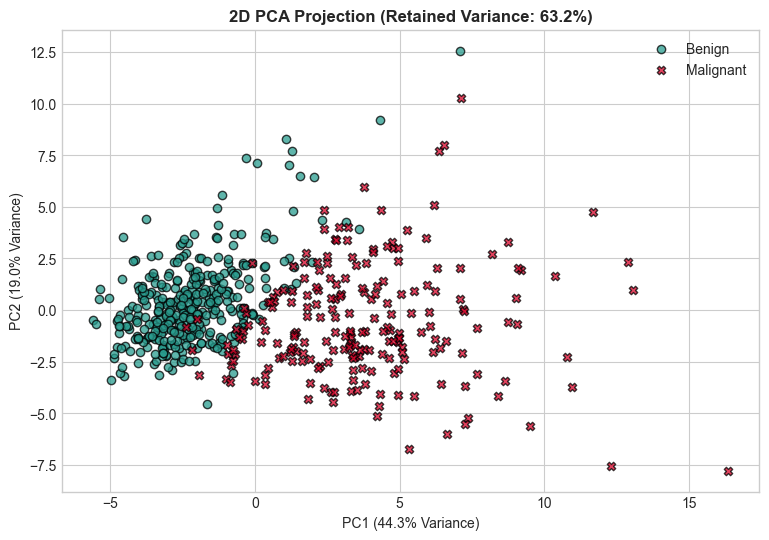

In [4]:
plt.figure(figsize=(9, 6))
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='#2a9d8f', label='Benign', alpha=0.75, edgecolors='black')
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='#d90429', marker='X', label='Malignant', alpha=0.75, edgecolors='black')
plt.title(f'2D PCA Projection (Retained Variance: {cum_evr*100:.1f}%)', fontweight='bold')
plt.xlabel(f'PC1 ({evr[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({evr[1]*100:.1f}% Variance)')
plt.legend()
plt.show()

## 4. Scree Plot Analysis Across All 30 Components

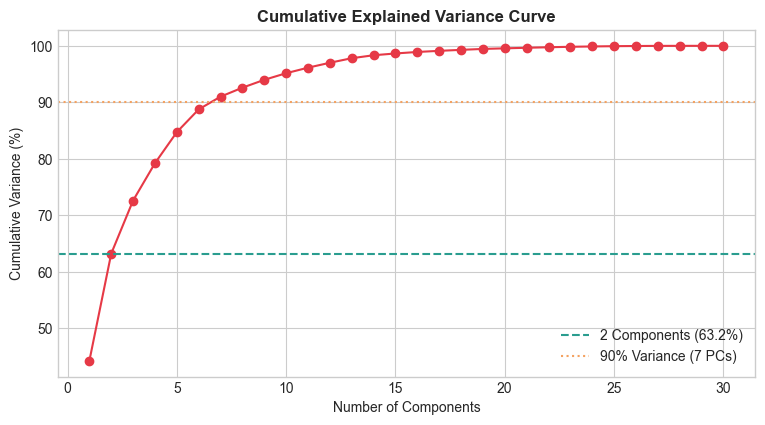

In [5]:
pca_full = PCA().fit(X_scaled)
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 31), np.cumsum(pca_full.explained_variance_ratio_)*100, 'o-', color='#e63946')
plt.axhline(cum_evr*100, color='#2a9d8f', linestyle='--', label=f'2 Components ({cum_evr*100:.1f}%)')
plt.axhline(90, color='#f4a261', linestyle=':', label='90% Variance (7 PCs)')
plt.title('Cumulative Explained Variance Curve', fontweight='bold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.legend()
plt.show()

## 5. What Retained Variance Means in Practice

1. **Information Compression Ratio**:
   We compressed 30 dimensions down to 2 dimensions—a **93.3% reduction in dimensionality**—while still preserving **{cum_evr*100:.2f}% of the total informational variance** in the dataset.

2. **Effective Class Separability**:
   Even though we discarded ~36.7% of the variance, the 2D projection demonstrates clean visual separation between Malignant and Benign tumors. This proves that the first two principal axes capture the underlying biological signal rather than arbitrary noise.

3. **Noise Filtering**:
   The discarded 28 dimensions largely contain measurement noise, redundant colinear correlations, and minor sample fluctuations. PCA acts as an effective denoising filter.